## ATACseq Data with over 500k entries 

each row (=entry) is a OCR peak. The set tells us how strong the peak is in each of the 89 immune cell types  
The data also includes Metadata for each of those peaks:  

- **chrom**  
Chromosome on which the OCR is located  

- **Summit**  
Genomic coordinate of the "peak summit"  
--> position with the strongest ATACseq signal within the OCR  

- **mm10 cons_score**  
as in "evolutionary conservation score"  
--> functional importance (highest value = 1.00)  

- **-log10_bestPvalue**  
remember: p-value measures likelihood of the result being just background noise (small p-value --> likely not background noise)  
--> kleiner log, großer p-value, wahrscheinlich relevant

- **included in systematic analysis**  
Boolean / yes-no flag indicating whether the authors considered this OCR reliable enough for downstream analyses in the paper  

- **TSS**  
name of closest TSS gene

- **genes within 100kb**  
just lists all the genes in that range as str 


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from pathlib import Path
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv'
ATAC_data = pd.read_csv(ATAC_path)

df = pd.read_csv("data/ImmGenATAC18_AllOCRsInfo.csv")
df.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50


## <h1> ATAC_sequence Data_Clean_Up 

<h2> Handling Missing Values

In [118]:
missing_value = ATAC_data.isnull().sum()
missing_value[missing_value > 0]

Included.in.systematic.analysis    177716
TSS                                498303
genes.within.100Kb                  84885
dtype: int64

In [117]:
missing_value.head(10)

ImmGenATAC1219.peakID                   0
chrom                                   0
Summit                                  0
mm10.60way.phastCons_scores             0
_-log10_bestPvalue                      0
Included.in.systematic.analysis    177716
TSS                                498303
genes.within.100Kb                  84885
LTHSC.34-.BM                            0
LTHSC.34+.BM                            0
dtype: int64

**Missing value handling**: <p>
Wir haben nur in drei Kategorien missing values (NAs). In allen drei Kategorien steht NA allerdings nicht für einen wirklich fehlenden Wert, sondern gibt uns echte Informationen. Die NAs *Included.in.systematic.analysis* geben uns zum Beispiel Aufschluss darüber, welche ATAC-peaks nicht in der späteren Analyse vom Research team weiterverwendet wurde.
Alle NAs in *TSS* markieren distal Enhancer und Gene, die in ihrer unmittelbaren Nähe (100kbs) kein Gen besitzen, werden ebenfalls mit NA gekennzeichnet. <p>
Daher müssen wir auch keine fehlenden Werte entfernen.

<h2> P-Value Filtering

In [5]:
Minimum_pvalue = ATAC_data['_-log10_bestPvalue'].min()
number_minimum = (ATAC_data['_-log10_bestPvalue'] == Minimum_pvalue).sum()
ATAC_data[ATAC_data['_-log10_bestPvalue'] == Minimum_pvalue]

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
64295,ImmGenATAC1219.peak_64296,chr10,122421608,0.0,0.0,NaN,NaN,Avpr1a,0.41,0.1,...,0.1,0.10,0.11,0.11,0.11,0.11,0.34,0.11,0.11,0.11
508409,ImmGenATAC1219.peak_508410,chrX,106733598,0.0,0.0,NaN,NaN,NaN,0.41,0.1,...,0.1,0.29,0.11,0.47,0.52,0.14,0.10,0.11,0.51,0.11


**P-Value filtering**: <p>
Wir filtern die Werte nach P-Values und untersuchen den Datensatz nach auffällig niedrigen vs hohen p-Values. <br> Eventuell sollten hohe p-Values (niedriger log) aus dem Datensatz rausgenommen werden. <br> Eventuell könnte man eine bestimmten p-Value Grenze setzen (z.B. 0.05) und dann Werte darüber excluden. <p>
*TO BE CONTINUED...*

<h2> Filtering low-signal peaks or low-variance features
<h3> Filtering low-signal peaks

In [6]:
ATAC_pfiltered = ATAC_data[ATAC_data['_-log10_bestPvalue'] > -np.log10(0.05)]
ATAC_pfiltered
#len(ATAC_pfiltered)

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512588,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
512589,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
512590,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
512591,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


**ATAC_data nur mit Werten, die einen p-Value kleiner 0.05 haben** <p>
1/3 von Werten haben einen p-Value der größer ist als 0.05, daher könnten diese Werte eine geringere statistische Signifikanz haben. Für unsere Nalyse ist es allerdings nicht sinnvoll, all diese Werte zu vernachlässigen.

In [7]:
ATAC_NA_pvalue = ATAC_data[
    (ATAC_data['_-log10_bestPvalue'] < -np.log10(0.05)) &
    (ATAC_data['Included.in.systematic.analysis'].isnull())
]

#Zeilen, die in Included.in.systematic.analysis NA stehen haben und gleichzeitig einen pValue von über 0.05 haben
# --> 150265 Werte (das entspricht allen Werten, deren p-Value über 0.05 ist)
# daher ist davon auszugehen, dass all diese Werte von Yoshida und Co. entfernt wurden (+noch mehr) 

len(ATAC_NA_pvalue)



150265

**Pre-Filtering im Yoshida Paper** <p>
Alle Werte, die einen p-Value von größer als 0.05 haben, wurden im Yoshida Paper auch von der Analyse ausgeschlossen (150265). Darüber hinaus haben Yoshida et al. noch weitere Werte nach eigenen bestimmten Kriterien Filering-Prozessen entfernt. Es würde für unsere Analyse daher Sinn ergeben, diesen Threshold von 0.05 anzuwenden, da diese Werte mindestens auch im Research von Paper von Yoshida entfernt wurden.


**Simons Zusatz:** <p>

- raw data (blacklist) anschauen & rausnehmen --> vielleicht included in pValue? müssen wir vergleichen
- Datensatz mal plotten (sollte normalverteilt sein)
- in GitHub Repo reinschauen (Fragen und so)

<h2> Blacklist Filtering:

In [8]:
from pathlib import Path
ATAC_path_blacklist = Path('data') / 'mm10.blacklist(2).bed'
ATAC_data_blacklist = pd.read_csv(ATAC_path_blacklist)

ATAC_data_blacklist
#df2.__len__()

,chr10\t3110060\t3110270
0,chr10\t22142530\t22142880
1,chr10\t22142830\t22143070
2,chr10\t58223870\t58224100
3,chr10\t58225260\t58225500
4,chr10\t58228320\t58228520
...,...
158,chr9\t3038050\t3038300
159,chr9\t24541940\t24542200
160,chr9\t35305120\t35305620
161,chr9\t110281190\t110281400


In [9]:
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]

ATAC_path_genanno = Path("data") / "Gene annotations.txt"

Gene_annotations = pd.read_csv(
    ATAC_path_genanno,
    sep="\t",
    names=cols
)

Gene_annotations.head()

,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
0,Wdsub1,NM_001159636,chr2,-,59855193,59882606,59855270,59878527,11,"59855193,59858609,59861560,59862619,59862816,5...","59855275,59858750,59861737,59862726,59862857,5..."
1,Rbm18,NM_001159635,chr2,-,36116078,36136704,36117814,36134247,6,"36116078,36120812,36122851,36127214,36134134,3...","36117974,36120898,36122938,36127251,36134263,3..."
2,Prrc2b,NM_001159634,chr2,+,32151147,32234537,32182511,32230742,32,"32151147,32182457,32183122,32185344,32187480,3...","32151291,32182626,32183300,32185447,32187553,3..."
3,Ildr2,NM_001164528,chr1,+,166254138,166316832,166254375,166310795,10,"166254138,166269304,166270498,166291415,166294...","166254466,166269637,166270618,166291472,166294..."
4,Perm1,NM_172417,chr4,+,156215926,156221307,156217000,156220222,4,"156215926,156216716,156219740,156220109,","156215975,156219185,156219866,156221307,"


In [120]:
Gene_annotations[Gene_annotations["txStart"] == 59855193]
(Gene_annotations['txStart'] == 59855193).any() #positiv Probe wird gefunden

np.True_

In [11]:
Gene_annotations[Gene_annotations["txStart"] == 24541940]
#or
(Gene_annotations["txStart"] == 24541940).any() #Start von blacklisted Beispiel-gen ist nicht zu finden

np.False_

Wir haben die blacklisted Gene als Tabelle auslesen lassen und dann die Startnummern mit denen der annotierten Gene im Gene annotations Dataset verglichen. Die blacklisted Gene sind nicht im Gene annotations Dataset wiederzufinden, daher ist davon auszugehen, dass diese blacklisted Gene bereits zu Beginn des Data Cleanups von Yoshida et al. entfernt wurde.

<h2> Log-Transformation


In [ ]:
log_ATAC_pfiltered = ATAC_pfiltered.copy()
log_ATAC_pfiltered.iloc[:,8:] = np.log1p(log_ATAC_pfiltered.iloc[:,8:])
log_ATAC_pfiltered.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,1.211941,0.095310,...,0.625938,0.431782,1.313724,0.667829,0.104360,4.164803,2.294553,0.845868,0.712950,0.104360
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.343590,0.095310,...,0.364643,1.040277,0.506818,0.104360,0.652325,2.674149,0.683097,0.824175,0.712950,0.104360
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.343590,0.095310,...,0.364643,0.095310,0.506818,1.026042,0.412110,0.652325,0.559616,0.845868,0.959350,1.704748
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,1.211941,0.970779,...,0.850151,0.254642,0.207014,0.636577,0.104360,0.425268,0.875469,0.641854,1.353255,2.311545
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.343590,0.095310,...,0.625938,1.075002,0.463734,0.104360,0.871293,1.275363,0.559616,1.193922,1.205971,2.486572


**Funktion zur log_transformation**
<p> Um bestimmte Datenanalyse Verfahren zu verwenden (Clustering, PCA, Regression) benötigt man einen normalverteilten Datensatz... Daher muss mit den ATAC-Daten eine log transformation durchgeführt werden


<h4> <b> Allgemeine Vorbereitung

In [13]:
ATAC_path_Tgd = Path('data') / 'ATAC_seq_gd_anot.csv'
ATAC_Tgd = pd.read_csv(ATAC_path_Tgd)
ATAC_Tgd.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,0.11,0.40,...,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.11,0.46,...,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.11,0.77,...,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,1.58,0.77,...,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.11,0.40,...,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73


In [14]:
import scipy.stats as stats
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq = RNA_seq.set_index("Unnamed: 0")  # Gennamen als Index setzen

Tgd_cells = [
    "MPP4.135+.BM",
    "preT.DN1.Th",
    "preT.DN2a.Th",
    "preT.DN2b.Th",
    "preT.DN3.Th",
    "T.DN4.Th",
    "Tgd.g1.1+d1.24a+.Th",
    "Tgd.g2+d1.24a+.Th",
    "Tgd.g2+d17.24a+.Th",
    "Tgd.Sp",
    "Tgd.g1.1+d1.LN",
    "Tgd.g2+d1.LN",
    "Tgd.g2+d17.LN"
]

RNA_Tgd = RNA_seq[Tgd_cells].copy()
RNA_Tgd.head()


,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
Unnamed: 0,,,,,,,,,,,,,
0610005C13Rik,1.021812,1.022363,1.389747,1.024819,1.024482,1.026430,1.023995,1.167561,1.024819,1.023995,1.025543,1.024819,1.023995
0610007P14Rik,204.298358,162.641117,206.945221,209.187788,198.421365,215.056475,150.742022,174.031477,115.930664,136.200789,108.850425,102.701399,137.925015
0610009B22Rik,76.418169,68.070719,82.468806,89.769337,57.661619,76.399214,47.775227,44.980534,53.461136,42.439750,28.755395,21.517647,29.122837
0610009L18Rik,16.947354,15.450717,13.573968,14.427620,8.249482,1.683173,8.554990,8.781962,29.156630,8.937625,10.815319,10.202163,9.033355
0610009O20Rik,186.261464,160.246297,125.475307,155.928005,120.692893,118.433597,94.062684,113.600798,102.445617,79.315094,84.643541,106.186930,86.383381


In [15]:
meta_cols = ["TSS", "genes.within.100Kb", "_-log10_bestPvalue", "Included.in.systematic.analysis",
             "ImmGenATAC1219.peakID", "chrom", "Summit", "mm10.60way.phastCons_scores"]
signal_cols_all = [col for col in ATAC_pfiltered.columns 
                   if col not in meta_cols 
                   and col in RNA_seq.columns] #alle Zelltypen Spaltennamen in ATAC, 
#ohne meta_cols und nur, wenn in ATAC, aber als liste und
signal_cols_all

signal_cols_tgd = Tgd_cells 

## <h1> 1.2 Enhancer vs Promoter (Accessibility signatures)

<h2> Preparing promoter vs enhancer dataset 

In [16]:
ATAC_enhancers = ATAC_pfiltered[ATAC_pfiltered["TSS"].isnull()]
ATAC_enhancers

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,2.36,1.64,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.41,0.10,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512588,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,0.41,7.41,...,4.98,4.47,2.83,4.93,4.92,5.13,9.13,2.21,6.53,6.11
512589,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.36,8.79,...,4.03,4.07,5.87,5.36,3.99,7.12,3.57,2.64,5.59,3.64
512590,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
512591,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64


In [17]:
ATAC_promoters = ATAC_pfiltered[-ATAC_pfiltered["TSS"].isnull()]
ATAC_promoters

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
20,ImmGenATAC1219.peak_21,chr1,3671437,0.72,2.02,1.0,Xkr4,Xkr4,0.41,3.68,...,2.53,0.10,0.11,1.87,0.92,4.97,2.62,2.64,2.83,17.14
139,ImmGenATAC1219.peak_140,chr1,4785675,0.41,15.87,1.0,Mrpl15,"Mrpl15,Lypla1,Tcea1",9.93,20.06,...,21.99,24.19,21.76,22.06,20.80,33.25,23.63,20.90,13.30,22.38
145,ImmGenATAC1219.peak_146,chr1,4807877,0.47,25.12,1.0,Lypla1,"Mrpl15,Lypla1,Tcea1",29.54,42.40,...,26.85,17.69,41.52,42.24,42.23,32.82,31.65,38.34,26.68,33.27
157,ImmGenATAC1219.peak_158,chr1,4857752,0.12,45.65,1.0,Tcea1,"Mrpl15,Lypla1,Tcea1",115.42,141.25,...,80.17,108.52,85.43,79.55,92.80,133.71,85.20,101.38,137.79,129.55
159,ImmGenATAC1219.peak_160,chr1,4858351,0.02,7.78,1.0,Tcea1,"Mrpl15,Lypla1,Tcea1",4.37,6.07,...,10.55,11.20,10.07,10.37,9.80,8.34,8.76,17.31,8.39,11.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512467,ImmGenATAC1219.peak_512468,chrX_GL456233_random,39222,0.32,73.75,1.0,Vamp7,"Vamp7,Spry3",57.63,42.40,...,37.95,58.81,61.00,38.21,37.03,63.17,48.63,61.16,82.32,48.00
512477,ImmGenATAC1219.peak_512478,chrX_GL456233_random,159627,0.12,16.28,1.0,Tmlhe,"Spry3,Tmlhe",22.66,21.83,...,3.12,2.21,9.63,0.47,1.75,16.68,8.32,13.71,29.25,5.34
512506,ImmGenATAC1219.peak_512507,chrY,1010556,0.18,13.45,1.0,Eif2s3y,"Eif2s3y,Tspy-ps",12.99,11.79,...,21.53,20.30,17.67,20.86,16.23,9.28,24.00,12.94,11.58,18.65
512522,ImmGenATAC1219.peak_512523,chrY,1245808,0.18,18.59,1.0,Uty,"Uty,Ddx3y",19.40,25.33,...,34.26,34.61,21.57,23.95,24.12,30.97,36.01,30.23,38.30,35.58


<h2> Calculating mean and median values (promoter vs enhancer)

In [18]:
mean_promoters = ATAC_promoters.iloc[:,8:].mean(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
mean_promoters.mean() #


np.float64(26.801848038378665)

In [19]:
median_promoters = ATAC_promoters.iloc[:,8:].median(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
median_promoters.median() #

np.float64(16.315)

In [20]:
mean_enhancers = ATAC_enhancers.iloc[:,8:].mean(axis=1)
mean_enhancers.mean()

np.float64(4.241589833922086)

In [21]:
median_enhancers = ATAC_enhancers.iloc[:,8:].median(axis=1)
median_enhancers.median()

np.float64(1.455)

**Mean ATAC readout signal: Enhancers vs promoters** <p>
The signal peaks that were identified as promoters/TSS show a way higher mean signal across all celltypes than the enhancers (26.801848038378665 vs 4.241589833922086). The median shows a similar trend. To proof whether the mean or the median are more accurate, one needs to take a look at promoter vs enhancer signal distributions and things such as the standard derivation and variance.

<h2> Plotting enhancer vs promoter

<Axes: xlabel='DC.4+.Sp', ylabel='Count'>

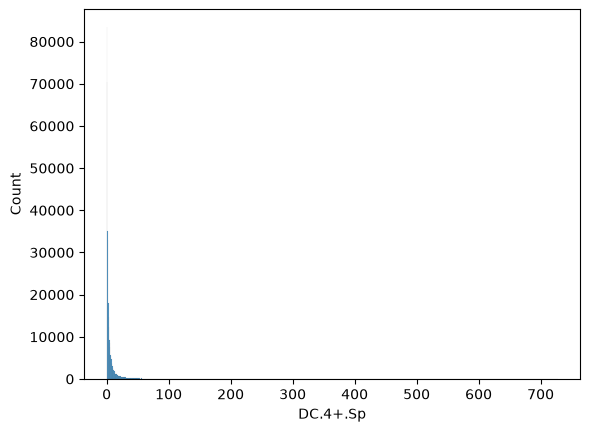

In [22]:
sns.histplot(data=ATAC_pfiltered.iloc[:,8:], x= "DC.4+.Sp" )

<Axes: xlabel='DC.4+.Sp', ylabel='Count'>

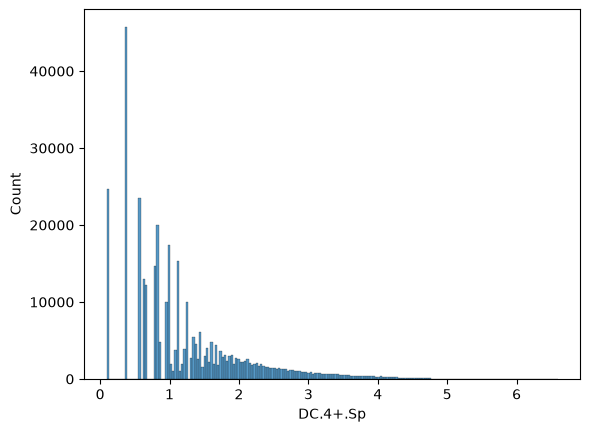

In [23]:
sns.histplot(data=log_ATAC_pfiltered.iloc[:,8:], x= "DC.4+.Sp" )

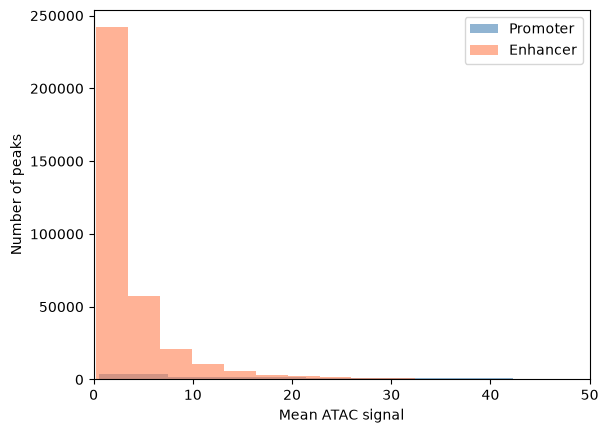

In [24]:
plt.hist(mean_promoters, bins=100, alpha=0.6, label='Promoter', color='steelblue')
plt.hist(mean_enhancers, bins=100, alpha=0.6, label='Enhancer', color='coral')
plt.xlim(0, 50) 
plt.xlabel('Mean ATAC signal')
plt.ylabel('Number of peaks')
plt.legend()

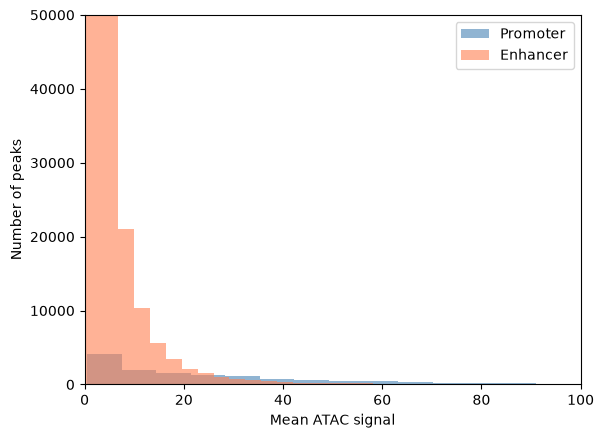

In [25]:
plt.hist(mean_promoters, bins=100, alpha=0.6, label='Promoter', color='steelblue')
plt.hist(mean_enhancers, bins=100, alpha=0.6, label='Enhancer', color='coral')
plt.xlim(0, 100) 
plt.ylim(0, 50000)
plt.xlabel('Mean ATAC signal')
plt.ylabel('Number of peaks')
plt.legend()

In [26]:
ATAC_pfiltered_extended = ATAC_pfiltered.copy() 
#ich erstelle mir einen erweiterten Datensatz, der neben dem normalen ATAC_pfiltered dataframe 
#noch weitere spalten mit den means, medians, stds und cvs enthält...
ATAC_pfiltered_extended["mean_signal"] = ATAC_pfiltered.iloc[:,8:].mean(axis=1)
ATAC_pfiltered_extended["median_signal"] = ATAC_pfiltered.iloc[:,8:].median(axis=1)
ATAC_pfiltered_extended["std_signal"] = ATAC_pfiltered.iloc[:,8:].std(axis=1)
ATAC_pfiltered_extended["cv_signal"] = ATAC_pfiltered_extended["std_signal"]/ATAC_pfiltered_extended["mean_signal"]

ATAC_pfiltered_extended["peak_type"] = np.where(
    ATAC_pfiltered_extended["TSS"].notna(), "Promoter", "Enhancer"
)
ATAC_pfiltered_extended[["peak_type", "mean_signal", "median_signal", "std_signal", "cv_signal"]]


,peak_type,mean_signal,median_signal,std_signal,cv_signal
2,Enhancer,1.521000,0.495,6.716484,4.415834
3,Enhancer,0.874556,0.530,1.533709,1.753701
4,Enhancer,0.882111,0.630,0.816587,0.925719
5,Enhancer,1.096556,0.785,1.218798,1.111478
6,Enhancer,0.944556,0.680,1.262417,1.336520
...,...,...,...,...,...
512588,Enhancer,5.823889,4.955,3.648828,0.626528
512589,Enhancer,5.526444,4.705,4.053177,0.733415
512590,Enhancer,6.936111,5.775,4.887909,0.704705
512591,Enhancer,6.995111,6.440,4.386282,0.627050


Text(0.5, 1.0, 'CV of Signal')

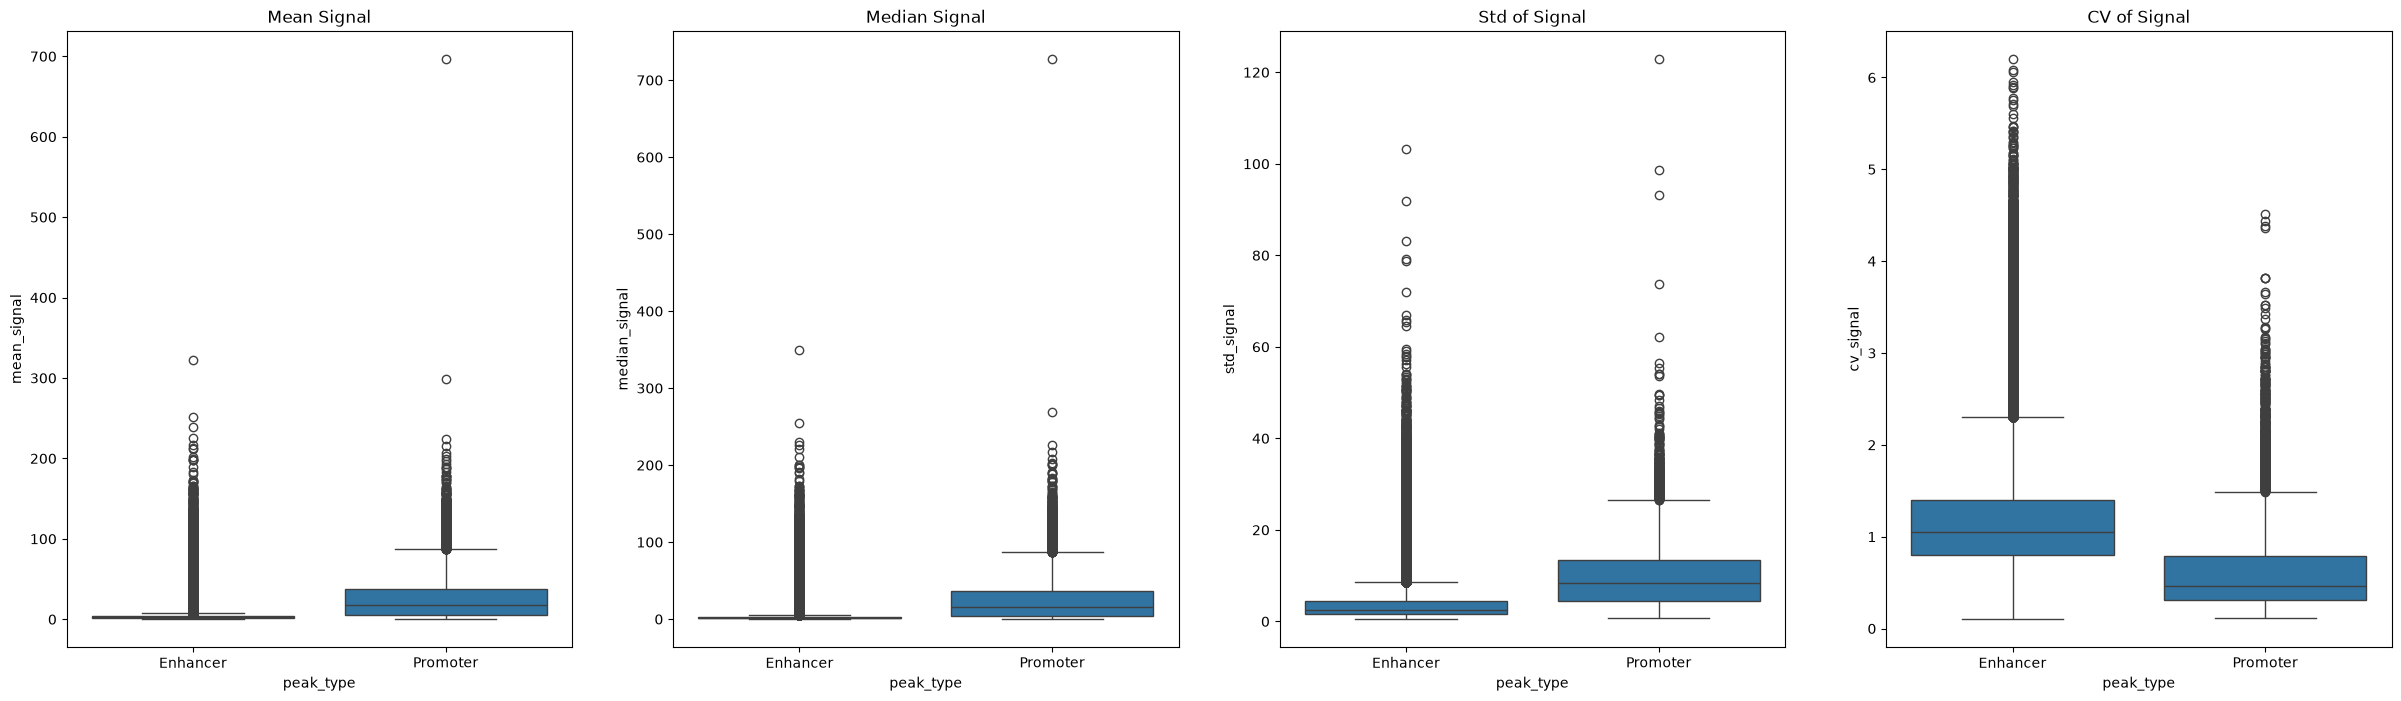

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(30, 8))
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="mean_signal", ax=axes[0])
axes[0].set_title("Mean Signal")
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="median_signal", ax=axes[1])
axes[1].set_title("Median Signal")
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="std_signal", ax=axes[2])
axes[2].set_title("Std of Signal")
sns.boxplot(data=ATAC_pfiltered_extended, x="peak_type", y="cv_signal",  ax=axes[3])
axes[3].set_title("CV of Signal")

C:\Users\lobe-\AppData\Local\Temp\ipykernel_24908\3476802171.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ATAC_pfiltered_extended, x='peak_type', y='mean_signal',
C:\Users\lobe-\AppData\Local\Temp\ipykernel_24908\3476802171.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ATAC_pfiltered_extended, x='peak_type', y='cv_signal',


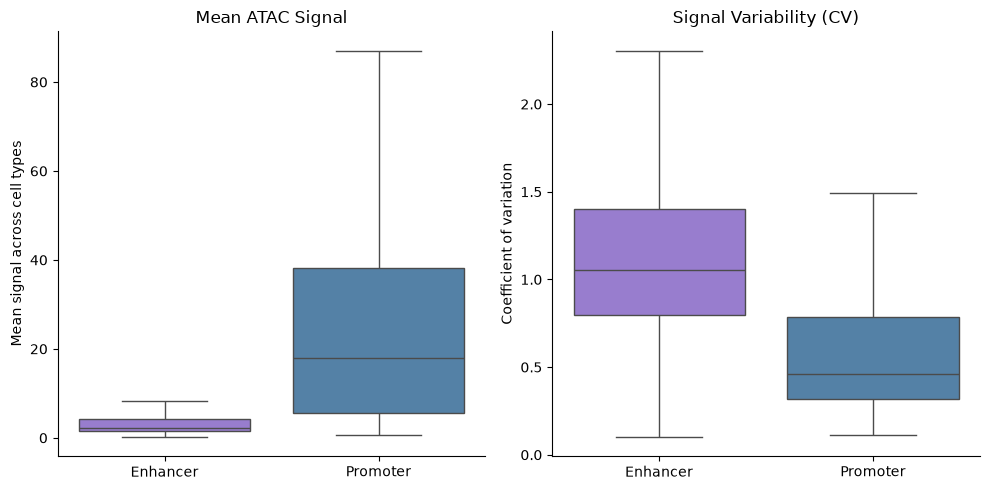

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Mean Signal
sns.boxplot(data=ATAC_pfiltered_extended, x='peak_type', y='mean_signal',
            palette={'Promoter': 'steelblue', 'Enhancer': 'mediumpurple'},
            showfliers=False, ax=axes[0])
axes[0].set_title("Mean ATAC Signal")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean signal across cell types")

# CV
sns.boxplot(data=ATAC_pfiltered_extended, x='peak_type', y='cv_signal',
            palette={'Promoter': 'steelblue', 'Enhancer': 'mediumpurple'},
            showfliers=False, ax=axes[1])
axes[1].set_title("Signal Variability (CV)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Coefficient of variation")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#plt.suptitle("Promoter vs. Enhancer OCR accessibility: all Immune cells", fontsize=13, y=1.02)
plt.savefig('plots_for_poster/Boxplot CV Enhancer_promoter all cells.png', dpi=300)
plt.tight_layout()
plt.show()

C:\Users\lobe-\AppData\Local\Temp\ipykernel_24908\2224975031.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ATAC_pfiltered_extended,


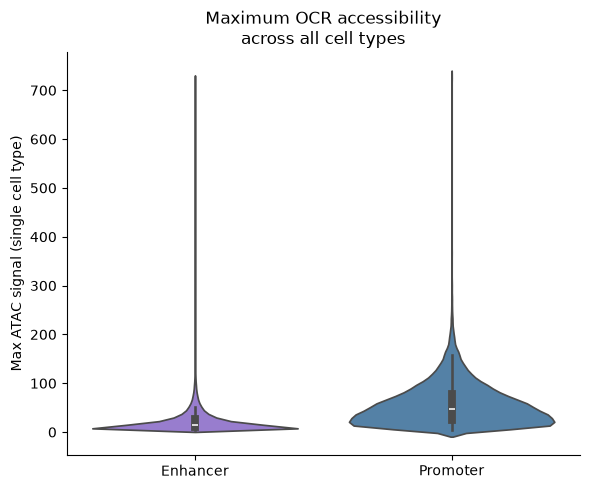

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Maximum Signal über alle Zelltypen pro Peak
ATAC_pfiltered_extended['max_signal'] = ATAC_pfiltered.iloc[:, 8:98].max(axis=1)

# Violinplot mit max_signal statt mean_signal
fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(data=ATAC_pfiltered_extended, 
               x='peak_type', y='max_signal',
               palette={'Promoter': 'steelblue', 'Enhancer': 'mediumpurple'},
               inner='box', ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Max ATAC signal (single cell type)")
ax.set_title("Maximum OCR accessibility\nacross all cell types")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [30]:
# Top 1% der Peaks pro Kategorie
top_enhancers = ATAC_pfiltered_extended[
    ATAC_pfiltered_extended['peak_type'] == 'Enhancer'
]['max_signal'].quantile(0.99)

top_promoters = ATAC_pfiltered_extended[
    ATAC_pfiltered_extended['peak_type'] == 'Promoter'
]['max_signal'].quantile(0.99)

print(f"Top 1% Enhancer max signal: {top_enhancers:.1f}")
print(f"Top 1% Promoter max signal: {top_promoters:.1f}")

Top 1% Enhancer max signal: 101.6
Top 1% Promoter max signal: 192.3


"While promoter OCRs show higher absolute chromatin accessibility than enhancer OCRs (top 1%: 192.3 vs. 101.6), enhancer OCRs exhibit greater signal variability across cell types (higher CV), consistent with their cell-type-specific activation patterns (Yoshida et al., 2019; Corces et al., 2018). This variability makes enhancers stronger discriminators of cell identity than promoters."

<h2> Calculating Std and Variance (promoter vs enhancer)

In [31]:
std_promoters = ATAC_promoters.iloc[:,8:].std(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
std_promoters.mean()

np.float64(9.735575860075166)

In [32]:
std_enhancers = ATAC_enhancers.iloc[:,8:].std(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
std_enhancers.mean()

np.float64(3.8733624583869357)

In [33]:
var_promoters = ATAC_promoters.iloc[:,8:].var(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
var_promoters.mean()

np.float64(143.22016480984846)

In [34]:
var_enhancers = ATAC_enhancers.iloc[:,8:].var(axis=1) #Mittelwert jedem Signalpeak über alle Zellen hinweg
var_enhancers.mean()

np.float64(30.960503552413734)

In [35]:
cv_enhancers = std_enhancers / mean_enhancers #Mittelwert jedem Signalpeak über alle Zellen hinweg
cv_enhancers.mean()

np.float64(1.1584095067846003)

In [36]:
cv_promoters = std_promoters / mean_promoters #Mittelwert jedem Signalpeak über alle Zellen hinweg
cv_promoters.mean()

np.float64(0.6224775768891224)

**Ohne Log-Transformation: verzerrte, nicht-vergleichbare Werte bei der Std (und dann auch bei Variance)** <p>
Promoter werden in allen zelltypen eher häufiger ausgelesen als enhancer, weil sie konstitutiv offen sind, enhancer sind eher entweder offen oder gecshlossen (ausgelesen oder nicht ausgelesen).... Daher sollten Enhancer eine größer standardabweichung haben, weil enhancer halt entweder 0 oder viel abgelesen werden während promoter im durschnitt eher gleich häufig in zellen ausgelesen werden --> Enhancer sind ja viel mehr zelltyp spezifisch... <br> Der kleinere std-Werte bei enhancer hier liegt daran, dass wir keine log transformation gemacht haben. Enhancer haben an und für sich einfach kleinere ATAC signals werte,dadurch einfach per default kleinere werte für die std.

**ABER: CV (Coefficient of Variation) ist aussagekräftig** <p>
Da der CV das Verhältnis zwischen std und mean berechnt, kann man anhand von diesem wert gut sehen, wie sehr ENhancer vs Promoter abweichen. Den Erwartungen entsprechend schwanken die Enhancer Werte deutlich mehr als die Promoter Werte.

<b> Notiz an mich: 
+ nochmal bitte nur mit unseren Zellen machen
+ Var und Std nochmal mit Z-Transformation

<h3> Enhancer vs Promoter: ATAC-correlation between all celltypes

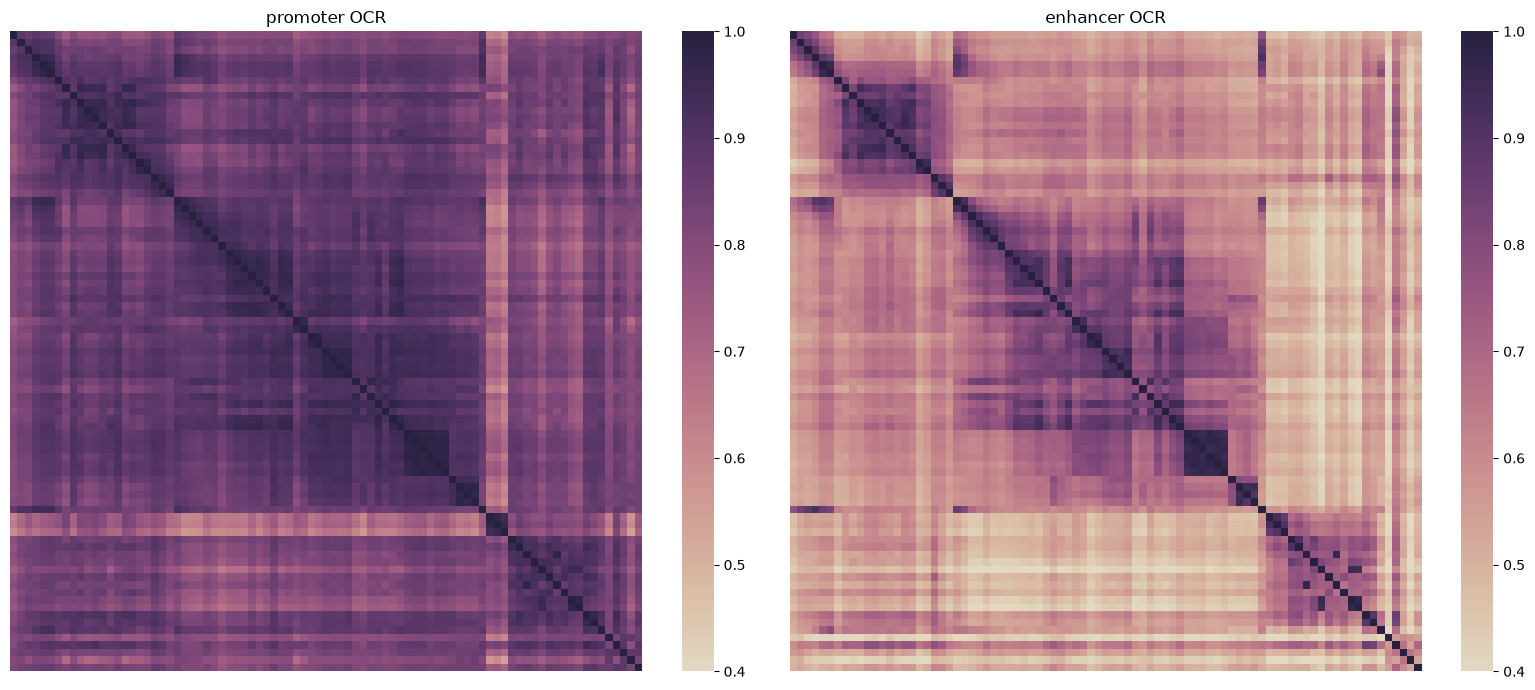

In [96]:

corr_promoter = ATAC_promoters[signal_cols_all].corr(method='pearson')
corr_enhancer  = ATAC_enhancers[signal_cols_all].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(corr_promoter, cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True), vmin=0.4, vmax=1,
            ax=axes[0], xticklabels=False, yticklabels=False)
axes[0].set_title("promoter OCR")
sns.color_palette("ch:s=-.2,r=.6", as_cmap=True)


sns.heatmap(corr_enhancer, cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True), vmin=0.4, vmax=1,
            ax=axes[1], xticklabels=False, yticklabels=False)
axes[1].set_title("enhancer OCR")

plt.savefig('plots_for_poster/enhancer_promoter ATAC heatmap all cells.png', dpi= 300, bbox_inches='tight')
plt.tight_layout()
plt.show()

<h3> Enhancer vs Promoter: ATAC-correlation between tgd celltypes

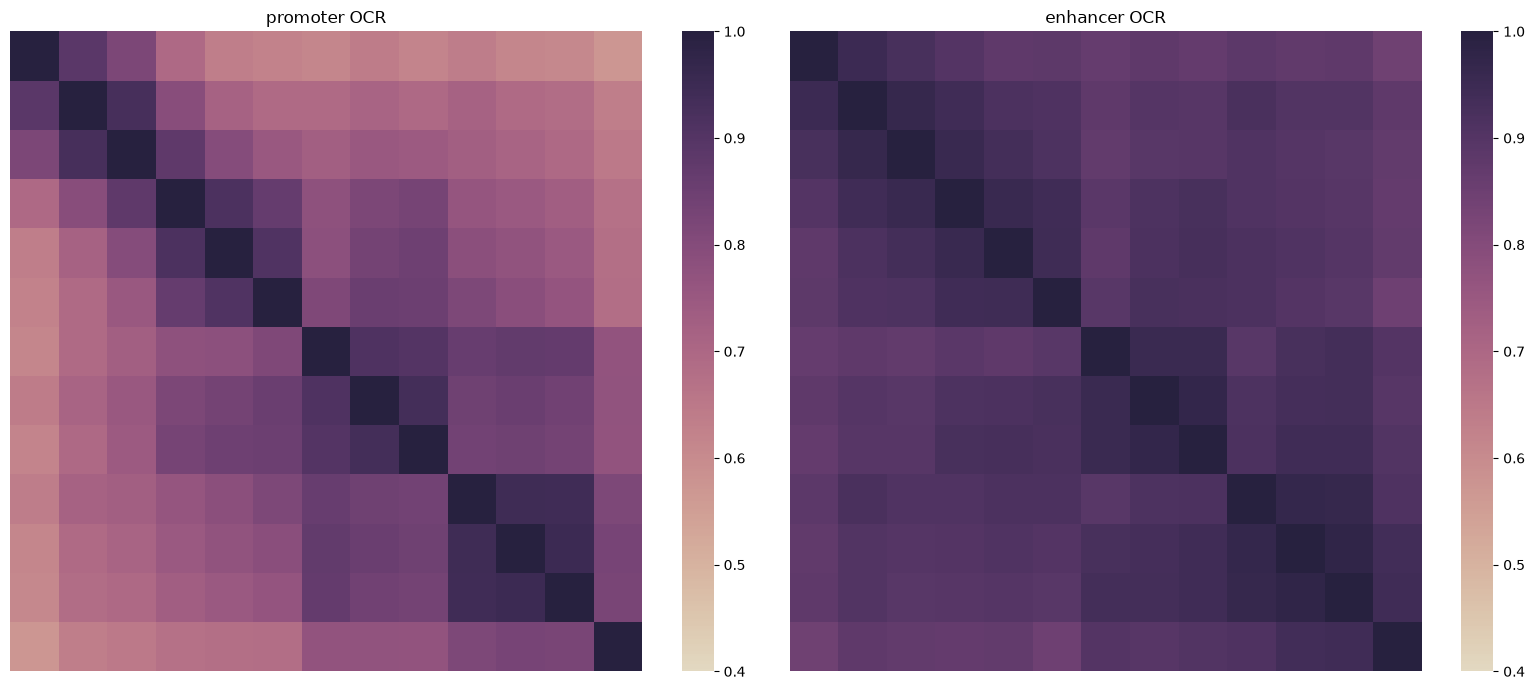

In [38]:
ATAC_promoter_tgd = ATAC_Tgd[ATAC_Tgd["TSS"].isna()]
ATAC_enhancer_tgd = ATAC_Tgd[ATAC_Tgd["TSS"].notna()]

corr_promoter_tgd = ATAC_promoter_tgd[signal_cols_tgd].corr(method='pearson')
corr_enhancer_tgd  = ATAC_enhancer_tgd[signal_cols_tgd].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(corr_promoter_tgd, cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True), vmin=0.4, vmax=1,
            ax=axes[0], xticklabels=False, yticklabels=False)
axes[0].set_title("promoter OCR")

sns.heatmap(corr_enhancer_tgd, cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True), vmin=0.4, vmax=1,
            ax=axes[1], xticklabels=False, yticklabels=False)
axes[1].set_title("enhancer OCR")

plt.tight_layout()
plt.show()

<b> Korrektur noch machen!!!
--> FDR

## <h1> 2.3 CRE–Gene Association via Correlation

<h3> Linking ATAC-seq peaks (our T-cels gd) to genes via Correlation

Idee: Nur peaks raussuchen, die in 100kb ein Gen haben (Spalte: genes within 100kb). Dann Signalpeak/Genpaare identifizieren. Für ATAC-Datensatz die Signalpeaks über die Zelltypen in einen Vektor packen. Für RNA-Datensatz die Genexpression von dem Gen über die Zelltypen in einen anderen Vektor... Dann Korrelation zwischen Signal peak (ATAC) und Genexpression (RNA)

In [39]:
ATAC_path_Tgd = Path('data') / 'ATAC_seq_gd_anot.csv'
ATAC_Tgd = pd.read_csv(ATAC_path_Tgd)
ATAC_Tgd.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,0.11,0.40,...,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.11,0.46,...,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.11,0.77,...,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,1.58,0.77,...,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.11,0.40,...,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73


In [40]:
ATAC_Tgd[-(ATAC_Tgd["genes.within.100Kb"].isnull())]


,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
11,ImmGenATAC1219.peak_18,chr1,3611363,0.16,3.32,1.0,NaN,Xkr4,0.11,0.11,...,0.87,1.02,0.58,0.40,0.41,0.53,0.51,0.11,1.95,0.73
12,ImmGenATAC1219.peak_19,chr1,3670859,0.76,1.74,1.0,NaN,Xkr4,3.04,4.73,...,2.82,6.59,2.69,1.33,3.82,2.35,1.29,0.99,1.39,3.33
13,ImmGenATAC1219.peak_20,chr1,3671114,0.94,2.02,1.0,NaN,Xkr4,4.84,4.73,...,4.73,5.18,4.47,0.54,2.72,1.48,1.29,0.99,0.68,2.60
14,ImmGenATAC1219.peak_21,chr1,3671437,0.72,2.02,1.0,Xkr4,Xkr4,4.84,2.48,...,3.14,2.29,6.44,0.84,2.69,1.11,4.59,3.12,2.96,0.13
15,ImmGenATAC1219.peak_22,chr1,3671783,0.91,9.67,1.0,NaN,Xkr4,2.58,1.80,...,3.71,3.07,2.76,0.11,2.58,0.97,1.04,2.23,1.33,0.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362325,ImmGenATAC1219.peak_512589,chrY,90811728,0.00,2.33,1.0,NaN,Erdr1,3.49,2.09,...,4.17,7.10,6.93,9.58,9.65,11.37,3.98,15.78,5.85,19.30
362326,ImmGenATAC1219.peak_512590,chrY,90812084,0.00,3.12,1.0,NaN,Erdr1,2.15,1.76,...,2.55,4.00,10.15,6.88,20.55,8.96,2.34,10.00,9.77,10.93
362327,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,2.58,3.32,...,3.37,4.55,8.41,8.61,19.64,8.96,3.61,13.42,14.05,9.01
362328,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,3.04,3.56,...,8.18,10.40,15.50,12.38,15.54,10.92,3.52,11.73,8.31,12.91


In [41]:
import scipy.stats as stats
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq.head()

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,0610005C13Rik,1.096732,1.096732,1.021750,1.021812,1.205236,1.326780,1.392996,1.821243,1.025543,...,1.025785,1.025785,1.251082,1.147249,1.024462,1.019656,1.017884,1.019107,1.017884,1.024720
1,0610007P14Rik,206.053987,246.105317,192.424636,204.298358,189.759175,210.195155,180.219440,137.802543,139.436719,...,121.603448,105.140895,101.841463,175.620707,280.406964,200.228029,208.171821,88.578590,129.021874,140.655763
2,0610009B22Rik,78.272059,78.837030,68.844751,76.418169,106.085619,77.502817,68.213092,57.224426,56.787489,...,88.691426,73.423656,68.881268,60.811907,56.578015,100.397766,37.373080,73.888468,77.191831,84.245816
3,0610009L18Rik,8.577159,16.791386,15.511549,16.947354,10.583704,8.664784,2.878172,8.952120,11.873984,...,6.132818,8.965889,4.080445,11.987408,5.627219,4.227673,2.199352,1.460090,2.482516,1.023995
4,0610009O20Rik,168.645852,157.926022,155.941641,186.261464,162.584556,152.088002,163.072291,133.116083,88.052982,...,102.592399,147.139323,130.924354,107.542142,88.338330,100.779150,86.442408,193.307175,187.212720,45.464889


In [42]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq = RNA_seq.set_index("Unnamed: 0")  # Gennamen als Index setzen

Tgd_cells = [
    "MPP4.135+.BM",
    "preT.DN1.Th",
    "preT.DN2a.Th",
    "preT.DN2b.Th",
    "preT.DN3.Th",
    "T.DN4.Th",
    "Tgd.g1.1+d1.24a+.Th",
    "Tgd.g2+d1.24a+.Th",
    "Tgd.g2+d17.24a+.Th",
    "Tgd.Sp",
    "Tgd.g1.1+d1.LN",
    "Tgd.g2+d1.LN",
    "Tgd.g2+d17.LN"
]

RNA_Tgd = RNA_seq[Tgd_cells].copy()
RNA_Tgd.head()


,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
Unnamed: 0,,,,,,,,,,,,,
0610005C13Rik,1.021812,1.022363,1.389747,1.024819,1.024482,1.026430,1.023995,1.167561,1.024819,1.023995,1.025543,1.024819,1.023995
0610007P14Rik,204.298358,162.641117,206.945221,209.187788,198.421365,215.056475,150.742022,174.031477,115.930664,136.200789,108.850425,102.701399,137.925015
0610009B22Rik,76.418169,68.070719,82.468806,89.769337,57.661619,76.399214,47.775227,44.980534,53.461136,42.439750,28.755395,21.517647,29.122837
0610009L18Rik,16.947354,15.450717,13.573968,14.427620,8.249482,1.683173,8.554990,8.781962,29.156630,8.937625,10.815319,10.202163,9.033355
0610009O20Rik,186.261464,160.246297,125.475307,155.928005,120.692893,118.433597,94.062684,113.600798,102.445617,79.315094,84.643541,106.186930,86.383381


<b> Korrelations-Analyse von Peak-Gen Paaren bei unseren Tgd-Zellen (13):

signal_cols_tgd = Tgd_cells 

results_corr_tgd = []

for peak_id, row in ATAC_Tgd[ATAC_Tgd["genes.within.100Kb"].notna()].iterrows():
    peak_signal = row[signal_cols_tgd].values.astype(float)
    gene = row["genes.within.100Kb"]

    for gene_name in str(gene).split(","):
        gene_name = gene_name.strip()

        if gene_name in RNA_Tgd.index:
            gene_expr = RNA_Tgd.loc[gene_name, signal_cols_tgd].values.astype(float)
            r, p = stats.pearsonr(peak_signal, gene_expr)

            results_corr_tgd.append({
                "peak_id": row["ImmGenATAC1219.peakID"],
                "gene":    gene_name,
                "r":       r,
                "p_value": p
            })

results_corr_tgd = pd.DataFrame(results_corr_tgd)
results_corr_tgd.to_csv('data/results_corr_tgd.csv', index=False) 

In [43]:
results_corr_tgd = pd.read_csv('data/results_corr_tgd.csv')
results_corr_all= pd.read_csv('data/results_corr_all.csv')

In [44]:
print(f"\nAnzahl Korrelationen von TGD-Zellen: {len(results_corr_tgd)}")


Anzahl Korrelationen von TGD-Zellen: 933713


In [45]:
results_corr_tgd.head()

,peak_id,gene,r,p_value
0,ImmGenATAC1219.peak_41,Rp1,-0.009633,0.975083
1,ImmGenATAC1219.peak_43,Rp1,0.060016,0.845581
2,ImmGenATAC1219.peak_46,Rp1,-0.319756,0.286869
3,ImmGenATAC1219.peak_48,Rp1,0.096712,0.753292
4,ImmGenATAC1219.peak_48,Sox17,0.121571,0.692373


In [46]:
results_corr_tgd[results_corr_tgd["r"] > 0.7].sort_values("r", ascending=False)

,peak_id,gene,r,p_value
1979,ImmGenATAC1219.peak_2086,Il17f,0.998686,1.509077e-15
483554,ImmGenATAC1219.peak_274985,Osbpl6,0.998488,3.255187e-15
1959,ImmGenATAC1219.peak_2075,Il17f,0.997891,2.031938e-14
1988,ImmGenATAC1219.peak_2090,Il17f,0.997714,3.162186e-14
338451,ImmGenATAC1219.peak_197929,Abi3bp,0.997449,5.776129e-14
...,...,...,...,...
732006,ImmGenATAC1219.peak_415764,Klra3,0.700007,7.721414e-03
84298,ImmGenATAC1219.peak_54750,Mrpl54,0.700006,7.721590e-03
879679,ImmGenATAC1219.peak_481899,C2cd2l,0.700005,7.721652e-03
483160,ImmGenATAC1219.peak_274706,Nfe2l2,0.700001,7.722104e-03


In [47]:
results_corr_tgd[results_corr_tgd["r"] < -0.7].sort_values("r")

,peak_id,gene,r,p_value
384631,ImmGenATAC1219.peak_216182,1700001C19Rik,-0.964467,1.061594e-07
98985,ImmGenATAC1219.peak_65109,B4galnt1,-0.959915,2.041892e-07
147483,ImmGenATAC1219.peak_83984,Fndc8,-0.944267,1.213607e-06
545115,ImmGenATAC1219.peak_311571,Clk2,-0.944156,1.226766e-06
831664,ImmGenATAC1219.peak_460272,D130040H23Rik,-0.943434,1.314735e-06
...,...,...,...,...
76889,ImmGenATAC1219.peak_53950,E130317F20Rik,-0.700046,7.716545e-03
150674,ImmGenATAC1219.peak_85076,Dhx40,-0.700031,7.718468e-03
533041,ImmGenATAC1219.peak_302989,Cetn4,-0.700006,7.721527e-03
760851,ImmGenATAC1219.peak_424697,Tbcb,-0.700006,7.721551e-03


hier habe ich mit der Pearson-Korrelation gearbeitet, da RNA und ATAC seq datensätze beide schon mal log transformiert wurden und quantile normalisiert, und dann zurück linearisiert... Im Yoshida paper benutzen die ebenfalls Pearson. Spearman hat bei annähernd normalverteilten daten eine geringere statistische power, da alles in ränge umgewandelt wird, die wertunterschiede gehen verloren...

<b> Bonferroni- Korrektur 

In [ ]:
results_corr_tgd = results_corr_tgd.dropna(subset=['p_value']) #man muss einen NaN Korrelationswert rausnehmen, weil das FDR verwirrt...

In [49]:
from statsmodels.stats.multitest import multipletests

# Bonferroni-Korrektur anwenden
_, p_bonf, _, _ = multipletests(results_corr_tgd['p_value'], method='bonferroni')
results_corr_tgd['p_bonf'] = p_bonf
#komische Schreibweise, aber multiple sets gibt vier werte zurück und uns interessieren nur die korrgierten p-Werte

# Filtern: nur signifikante Assoziationen behalten
corr_bonf_tgd = results_corr_tgd[results_corr_tgd['p_bonf'] < 0.05]
print(f"Signifikante Assoziationen: {len(corr_bonf_tgd)}")
print(f"Von insgesamt: {len(results_corr_tgd)}")

Signifikante Assoziationen: 303
Von insgesamt: 933712


In [50]:
corr_bonf_tgd.head() #303 übrig-gebliebende signifikante Werte

,peak_id,gene,r,p_value,p_bonf
1959,ImmGenATAC1219.peak_2075,Il17f,0.997891,2.031938e-14,1.897245e-08
1979,ImmGenATAC1219.peak_2086,Il17f,0.998686,1.509077e-15,1.409043e-09
1988,ImmGenATAC1219.peak_2090,Il17f,0.997714,3.162186e-14,2.952571e-08
1997,ImmGenATAC1219.peak_2095,Il17f,0.980563,3.966074e-09,3.703171e-03
2543,ImmGenATAC1219.peak_2573,Ogfrl1,0.977710,8.377823e-09,7.822474e-03


<b> FDR-Korrektur (Benjamini-Hochberg)

In [51]:
_ , p_fdr, _, _ = multipletests(results_corr_tgd['p_value'], method='fdr_bh')
results_corr_tgd['p_fdr'] = p_fdr
corr_fdr_tgd = results_corr_tgd[p_fdr < 0.05]

In [52]:
corr_fdr_tgd.head() #10248 übrig-gebliebende signifikante Werte

,peak_id,gene,r,p_value,p_bonf,p_fdr
232,ImmGenATAC1219.peak_229,Npbwr1,0.826966,0.000488,1.0,0.046927
326,ImmGenATAC1219.peak_412,Pcmtd1,0.828240,0.000470,1.0,0.046009
327,ImmGenATAC1219.peak_413,Pcmtd1,0.877619,0.000081,1.0,0.017123
613,ImmGenATAC1219.peak_616,Sgk3,0.867524,0.000122,1.0,0.021803
867,ImmGenATAC1219.peak_716,Arfgef1,0.828007,0.000473,1.0,0.046188


corr_bonf sind alle korrelations pairs, die nach der bonferroni korrektur noch als signfikant übrig bleiben. 

sehr wenige signfikante Werte, weil: wir arbeiten nur mit sehr wenigen Zellen... Alternativ könnte man mit dem gesamten Datensatz arbeiten, aber da könte die Ladedauer ewig sein... Im Yoshida peper haben die für diesen SChritt auch Bonferroni benutzt

Da wir ~933.000 (Peak, Gen)-Paare testen, würden bei α = 0.05 rein zufällig ~46.000 Paare als signifikant erscheinen (multiples Testen). Bonferroni korrigiert das, indem es α durch die Anzahl der Tests teilt (α ≈ 5×10⁻⁸) — bei nur 13 Zelltypen ist diese Schwelle aber kaum erreichbar und verwirft echte Assoziationen. Wir verwenden daher FDR (Benjamini-Hochberg), das in der Genomik Standard ist und mehr statistische Power behält. Bei Bonfe haben wir am Ende nur noch 303 pairs, bei fdr 10248.

<b> Korrelations-Analyse von Peak-Gen Paaren bei allen Zellen (Exkurs):

In [53]:
meta_cols = ["TSS", "genes.within.100Kb", "_-log10_bestPvalue", "Included.in.systematic.analysis",
             "ImmGenATAC1219.peakID", "chrom", "Summit", "mm10.60way.phastCons_scores"]
signal_cols_all = [col for col in ATAC_pfiltered.columns 
                   if col not in meta_cols 
                   and col in RNA_seq.columns] #alle Zelltypen Spaltennamen in ATAC, 
#ohne meta_cols und nur, wenn in ATAC, aber als liste und
signal_cols_all

['LTHSC.34-.BM',
 'LTHSC.34+.BM',
 'STHSC.150-.BM',
 'MPP4.135+.BM',
 'proB.CLP.BM',
 'proB.FrA.BM',
 'proB.FrBC.BM',
 'B.FrE.BM',
 'B1b.PC',
 'B.T1.Sp',
 'B.T2.Sp',
 'B.T3.Sp',
 'B.Sp',
 'B.Fem.Sp',
 'B.MZ.Sp',
 'B.Fo.Sp',
 'B.mem.Sp',
 'B.GC.CB.Sp',
 'B.GC.CC.Sp',
 'B.PB.Sp',
 'B.PC.Sp',
 'B.PC.BM',
 'preT.DN1.Th',
 'preT.DN2a.Th',
 'preT.DN2b.Th',
 'preT.DN3.Th',
 'T.DN4.Th',
 'T.ISP.Th',
 'T.DP.Th',
 'T.4.Th',
 'T.8.Th',
 'T.4.Nve.Sp',
 'T.4.Nve.Fem.Sp',
 'T.8.Nve.Sp',
 'T.4.Sp.aCD3+CD40.18hr',
 'Treg.4.FP3+.Nrplo.Co',
 'Treg.4.25hi.Sp',
 'T8.TN.P14.Sp',
 'T8.TE.LCMV.d7.Sp',
 'T8.MP.LCMV.d7.Sp',
 'T8.Tcm.LCMV.d180.Sp',
 'T8.Tem.LCMV.d180.Sp',
 'NKT.Sp',
 'NKT.Sp.LPS.3hr',
 'NKT.Sp.LPS.18hr',
 'NKT.Sp.LPS.3d',
 'Tgd.g2+d17.24a+.Th',
 'Tgd.g2+d17.LN',
 'Tgd.g2+d1.24a+.Th',
 'Tgd.g2+d1.LN',
 'Tgd.g1.1+d1.24a+.Th',
 'Tgd.g1.1+d1.LN',
 'Tgd.Sp',
 'NK.27+11b-.BM',
 'NK.27+11b+.BM',
 'NK.27-11b+.BM',
 'NK.27+11b-.Sp',
 'NK.27+11b+.Sp',
 'NK.27-11b+.Sp',
 'ILC2.SI',
 'ILC3.NKp46-CCR6-.SI',

results_corr_all = []

for peak_id, row in ATAC_pfiltered[ATAC_pfiltered["genes.within.100Kb"].notna()].iterrows():
    peak_signal = row[signal_cols_all].values.astype(float)
    gene = row["genes.within.100Kb"]

    for gene_name in str(gene).split(","):
        gene_name = gene_name.strip()

        if gene_name in RNA_seq.index:
            gene_expr = RNA_seq.loc[gene_name, signal_cols_all].values.astype(float)
            r, p = stats.pearsonr(peak_signal, gene_expr)

            results_corr_all.append({
                "peak_id": row["ImmGenATAC1219.peakID"],
                "gene":    gene_name,
                "r":       r,
                "p_value": p
            })

results_corr_all = pd.DataFrame(results_corr_all)
results_corr_all.to_csv('data/results_corr_all.csv', index=False) 

ich nutze hier die stats korrelations funktion, weil die mir gleich den p-wert berechnet... den brauche ich für die korrekturen. mit dem normalen panda series corr() habe ich nur den r-wert und müsste den p-wert manuell bestimmen

In [54]:
print(f"\nAnzahl Korrelationen von allen Zellen: {len(results_corr_all)}")


Anzahl Korrelationen von allen Zellen: 933713


In [55]:
results_corr_all.head()

,peak_id,gene,r,p_value
0,ImmGenATAC1219.peak_41,Rp1,-0.078288,4.763487e-01
1,ImmGenATAC1219.peak_43,Rp1,-0.131412,2.305944e-01
2,ImmGenATAC1219.peak_46,Rp1,0.373676,4.272850e-04
3,ImmGenATAC1219.peak_48,Rp1,0.803798,2.052007e-20
4,ImmGenATAC1219.peak_48,Sox17,0.022633,8.370992e-01


In [56]:
results_corr_all[results_corr_all["r"] > 0.7].sort_values("r")

,peak_id,gene,r,p_value
332448,ImmGenATAC1219.peak_193454,Itgb5,0.700003,9.012261e-14
31935,ImmGenATAC1219.peak_22791,Shisa4,0.700008,9.007129e-14
581111,ImmGenATAC1219.peak_332683,5730488B01Rik,0.700018,8.997207e-14
593063,ImmGenATAC1219.peak_343934,Yipf1,0.700022,8.993124e-14
917778,ImmGenATAC1219.peak_501440,Ccr9,0.700024,8.990992e-14
...,...,...,...,...
485282,ImmGenATAC1219.peak_276303,Serping1,0.995585,4.569541e-87
794941,ImmGenATAC1219.peak_441054,Calcb,0.995828,4.380303e-88
41801,ImmGenATAC1219.peak_30580,Ddr2,0.996070,3.683310e-89
196043,ImmGenATAC1219.peak_104763,Clec14a,0.996494,3.267506e-91


In [57]:
len(results_corr_all[results_corr_all["r"] > 0.7].sort_values("r"))

16743

In [58]:
len(results_corr_tgd[results_corr_tgd["r"] > 0.7].sort_values("r"))

30925

In [59]:
results_corr_all[results_corr_all["r"] < -0.7].sort_values("r")

,peak_id,gene,r,p_value
799232,ImmGenATAC1219.peak_444008,Lat,-0.733080,1.504707e-15
929593,ImmGenATAC1219.peak_509214,Btk,-0.722989,5.581734e-15
874697,ImmGenATAC1219.peak_478534,Vps26b,-0.722896,5.648135e-15
702325,ImmGenATAC1219.peak_401472,Eif2ak3,-0.722858,5.675038e-15
132811,ImmGenATAC1219.peak_79952,Trp53,-0.722285,6.102988e-15
682133,ImmGenATAC1219.peak_386810,Rnf216,-0.719037,9.182620e-15
484851,ImmGenATAC1219.peak_276252,Clp1,-0.718876,9.369464e-15
905381,ImmGenATAC1219.peak_496615,Vprbp,-0.707943,3.553768e-14
726600,ImmGenATAC1219.peak_413884,Ltbr,-0.705403,4.802000e-14


In [60]:
_ , p_fdr, _, _ = multipletests(results_corr_all['p_value'], method='fdr_bh')
results_corr_all['p_fdr'] = p_fdr
corr_fdr_all = results_corr_all[p_fdr < 0.05]

In [61]:
len(corr_fdr_all)

188177

In [62]:
corr_fdr_all.head()

,peak_id,gene,r,p_value,p_fdr
2,ImmGenATAC1219.peak_46,Rp1,0.373676,4.272850e-04,3.650719e-03
3,ImmGenATAC1219.peak_48,Rp1,0.803798,2.052007e-20,2.529354e-18
7,ImmGenATAC1219.peak_52,Rp1,0.725175,4.222263e-15,2.807964e-13
8,ImmGenATAC1219.peak_52,Sox17,0.422994,5.504399e-05,6.168644e-04
9,ImmGenATAC1219.peak_53,Rp1,0.876096,5.013480e-28,1.352543e-25


Mit mehr Zelltypen als Korrelations-pair basis haben wir zwar weniger werte mit einem korrelationswert r über 0.7, allerdings haben wir viel mehr mit einem stabilen p-wert und somit viel mehr, die den fdr test bestehen. denn bei den 13 zelltypen gibt es mehr schwankungen, also zufällig hohe r werte, die dann aber nicht signifikant sind. die erhöhung der zelltypen als basis macht die r wert robuster und die korrelation aussagekräftiger.

<h3> Distanz von den peaks zu TSS-Start berechnen

<h4> Tgd-Zellen:

<b> FDR:

In [63]:
# Peak_Summit aus ATAC in corr_fdr reinmergen
corr_fdr_tgd = results_corr_tgd[results_corr_tgd['p_fdr'] < 0.05].copy()

corr_fdr_tgd = corr_fdr_tgd.merge(
    ATAC_Tgd[['ImmGenATAC1219.peakID', 'Summit']], 
    left_on='peak_id', 
    right_on='ImmGenATAC1219.peakID'
).drop(columns='ImmGenATAC1219.peakID')

# TSS strangkorrekt bestimmen
Gene_annotations['TSS_pos'] = Gene_annotations.apply(
    lambda r: r['txStart'] if r['strand'] == '+' else r['txEnd'], axis=1
)

# TSS_pos in corr_fdr reinmergen
corr_fdr_tgd = corr_fdr_tgd.merge(
    Gene_annotations[['gene_name', 'TSS_pos']].drop_duplicates('gene_name'),
    left_on='gene', 
    right_on='gene_name'
)

# Distanz berechnen
corr_fdr_tgd['distance'] = corr_fdr_tgd['Summit'] - corr_fdr_tgd['TSS_pos']
corr_fdr_tgd = corr_fdr_tgd[corr_fdr_tgd['distance'].abs() <= 100_000]
corr_fdr_tgd[['peak_id', 'gene', 'r', 'distance']].head()

,peak_id,gene,r,distance
0,ImmGenATAC1219.peak_229,Npbwr1,0.826966,29086
1,ImmGenATAC1219.peak_412,Pcmtd1,0.828240,74719
2,ImmGenATAC1219.peak_413,Pcmtd1,0.877619,75027
3,ImmGenATAC1219.peak_616,Sgk3,0.867524,35523
4,ImmGenATAC1219.peak_716,Arfgef1,0.828007,-15555


<b> Bonferroni:

In [64]:
# Peak_Summit aus ATAC in corr_bonf reinmergen
corr_bonf_tgd = results_corr_tgd[results_corr_tgd['p_bonf'] < 0.05].copy()

corr_bonf_tgd = corr_bonf_tgd.merge(
    ATAC_Tgd[['ImmGenATAC1219.peakID', 'Summit']], 
    left_on='peak_id', 
    right_on='ImmGenATAC1219.peakID'
).drop(columns='ImmGenATAC1219.peakID')

# TSS strangkorrekt bestimmen
Gene_annotations['TSS_pos'] = Gene_annotations.apply(
    lambda r: r['txStart'] if r['strand'] == '+' else r['txEnd'], axis=1
)

# TSS_pos in corr_bonf reinmergen
corr_bonf_tgd = corr_bonf_tgd.merge(
    Gene_annotations[['gene_name', 'TSS_pos']].drop_duplicates('gene_name'),
    left_on='gene', 
    right_on='gene_name'
)

# Distanz berechnen
corr_bonf_tgd['distance'] = corr_bonf_tgd['Summit'] - corr_bonf_tgd['TSS_pos']
corr_bonf_tgd = corr_bonf_tgd[corr_bonf_tgd['distance'].abs() <= 100_000]
corr_bonf_tgd[['peak_id', 'gene', 'r', 'distance']].head()

,peak_id,gene,r,distance
0,ImmGenATAC1219.peak_2075,Il17f,0.997891,-98146
1,ImmGenATAC1219.peak_2086,Il17f,0.998686,-40200
2,ImmGenATAC1219.peak_2090,Il17f,0.997714,-24354
3,ImmGenATAC1219.peak_2095,Il17f,0.980563,77
4,ImmGenATAC1219.peak_2573,Ogfrl1,0.977710,50647


<h4> Alle Zellen:

<b> FDR:

In [65]:
# Peak_Summit aus ATAC in corr_fdr reinmergen
corr_fdr_all = results_corr_all[results_corr_all['p_fdr'] < 0.05].copy()

corr_fdr_all = corr_fdr_all.merge(
    ATAC_pfiltered[['ImmGenATAC1219.peakID', 'Summit']], 
    left_on='peak_id', 
    right_on='ImmGenATAC1219.peakID'
).drop(columns='ImmGenATAC1219.peakID')

# TSS strangkorrekt bestimmen
Gene_annotations['TSS_pos'] = Gene_annotations.apply(
    lambda r: r['txStart'] if r['strand'] == '+' else r['txEnd'], axis=1
)

# TSS_pos in corr_fdr reinmergen
corr_fdr_all = corr_fdr_all.merge(
    Gene_annotations[['gene_name', 'TSS_pos']].drop_duplicates('gene_name'),
    left_on='gene', 
    right_on='gene_name'
)

# Distanz berechnen
corr_fdr_all['distance'] = corr_fdr_all['Summit'] - corr_fdr_all['TSS_pos']
corr_fdr_all = corr_fdr_all[corr_fdr_all['distance'].abs() <= 100_000]
corr_fdr_all[['peak_id', 'gene', 'r', 'distance']].head()

,peak_id,gene,r,distance
0,ImmGenATAC1219.peak_46,Rp1,0.373676,-57194
1,ImmGenATAC1219.peak_48,Rp1,0.803798,-7553
2,ImmGenATAC1219.peak_52,Rp1,0.725175,3497
3,ImmGenATAC1219.peak_52,Sox17,0.422994,-84616
4,ImmGenATAC1219.peak_53,Rp1,0.876096,5154


<h3> Wo liegen die Assoziationen relativ zum TSS? Wo sind die am dichtesten?

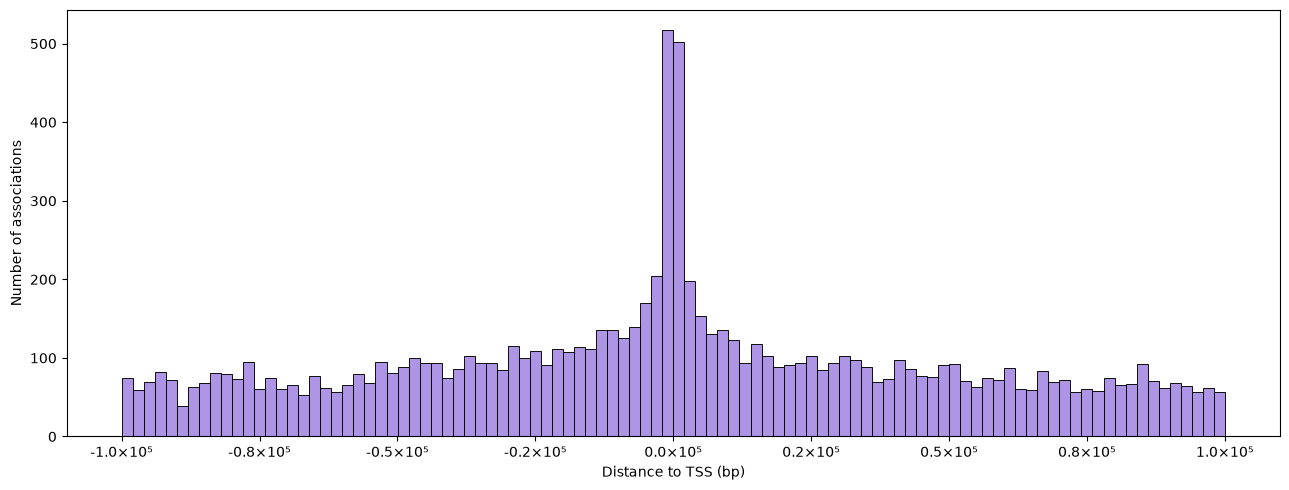

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

sns.histplot(
    data=corr_fdr_tgd,        #ganzer DataFrame
    x="distance",              #Spaltenname
    bins=100,
    color="mediumpurple",
    ax=ax
)

ax.set_xlabel("Distance to TSS (bp)")
ax.set_ylabel("Number of associations")
#ax.set_title("Distribution of significant correlated OCRs (FDR) in γδT cells relative to TSS")

# x-Achse in 100kb-Einheiten wie Yoshida
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e5:.1f}×10⁵")
)
plt.savefig('plots_for_poster/single Barplot DIstance of correlated OCRs to TSS.png', dpi= 300)
plt.tight_layout()
plt.show()

<b> Vergleich Distanzverteilung von korrelierten ORCs zwischen Tgd-Zellen und allen Zellen

Text(0.5, 1.02, 'Distance of significant correlated ORCs to TSS')

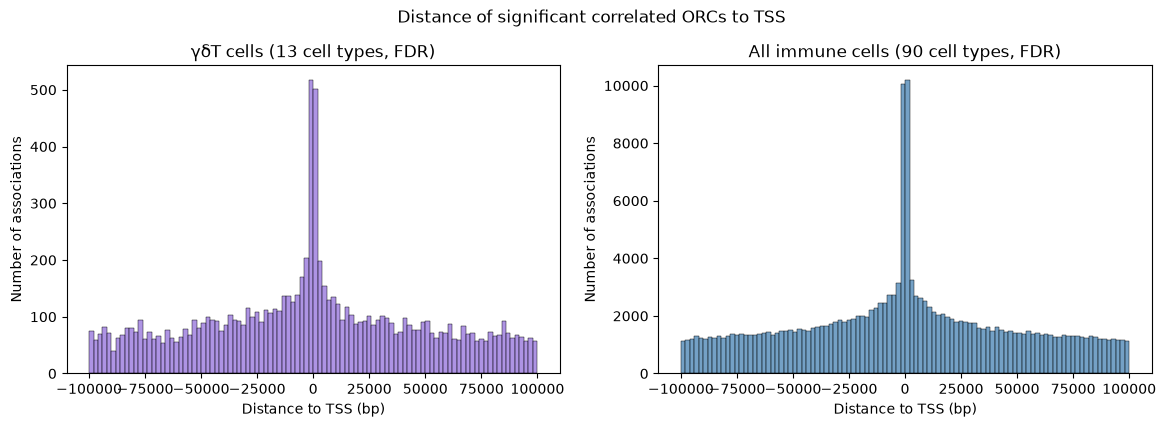

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# γδT
sns.histplot(data=corr_fdr_tgd, x="distance", bins=100, 
             color="mediumpurple", ax=axes[0])
axes[0].set_title("γδT cells (13 cell types, FDR)")
axes[0].set_xlabel("Distance to TSS (bp)")
axes[0].set_ylabel("Number of associations")


# All cells
sns.histplot(data=corr_fdr_all, x="distance", bins=100,
             color="steelblue", ax=axes[1])
axes[1].set_title("All immune cells (90 cell types, FDR)")
axes[1].set_xlabel("Distance to TSS (bp)")
axes[1].set_ylabel("Number of associations")

fig.suptitle(
    "Distance of significant correlated ORCs to TSS",
    fontsize=12, y=1.02
)

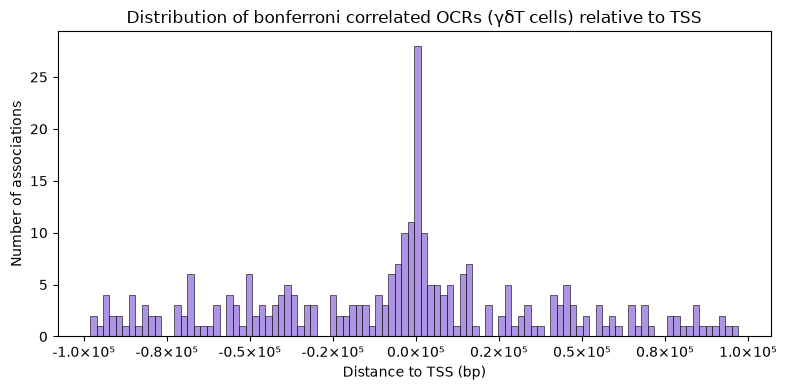

In [68]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=corr_bonf_tgd,        # ganzer DataFrame
    x="distance",              # Spaltenname
    bins=100,
    color="mediumpurple",
    ax=ax
)

ax.set_xlabel("Distance to TSS (bp)")
ax.set_ylabel("Number of associations")
ax.set_title("Distribution of bonferroni correlated OCRs (γδT cells) relative to TSS")

# x-Achse in 100kb-Einheiten wie Yoshida
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e5:.1f}×10⁵")
)

plt.tight_layout()
plt.show()

Unsere plots sehen ein wenig anders aus als der plot von yoshida (3C). das liegt zum einen an der geringeren zellzahl, wir schauen hier nur auf die 13 von uns gewählten zelle. außerdem nutzen wir beim ersten plot die korrektur fdr statt bonferroni, daher überleben mehr weiter vom TSS entfernte assoziation pairs. der hintergrund ist hier flacher und der abfall bei entfernung zum TSS wneiger stark, allerdings haben wir bei fdr mehr gene. Der bonferroni plot ähnelt eher dem yoshida plot.

<h3> How many CREs are typically associated with a single gene?

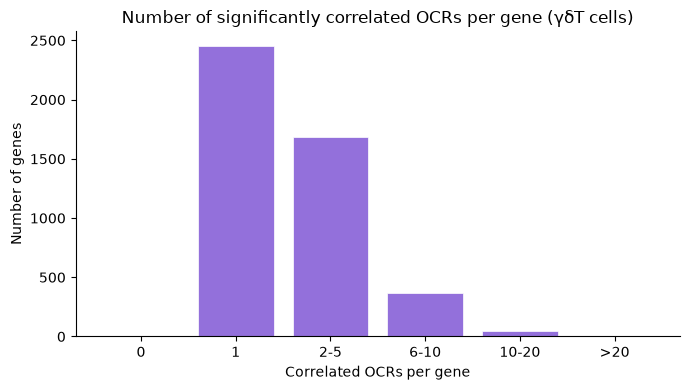

In [69]:
# Anzahl OCRs pro Gen zählen
ocrs_per_gene = corr_fdr_tgd.groupby('gene')['peak_id'].count().reset_index()
ocrs_per_gene.columns = ['gene', 'n_ocrs']

# Kategorien wie Yoshida
bins = [0, 1, 2, 5, 10, 20, np.inf]
labels = ['0', '1', '2-5', '6-10', '10-20', '>20']
ocrs_per_gene['category'] = pd.cut(ocrs_per_gene['n_ocrs'], bins=bins, labels=labels, right=False)

counts = ocrs_per_gene['category'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, counts, color='mediumpurple', edgecolor='white', linewidth=0.5)
ax.set_xlabel("Correlated OCRs per gene")
ax.set_ylabel("Number of genes")
ax.set_title("Number of significantly correlated OCRs per gene (γδT cells)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

<h3> Example: Correlation of strongest correlated gene

<b> Nur Tgd-Zellen:

In [70]:
# Stärkstes Gen aus sig auswählen (höchstes r)
best = corr_fdr_all.loc[corr_fdr_all['r'].idxmax()]
gene_name = best['gene']
peak_name_all = best['peak_id']

gene_name

'Paqr9'

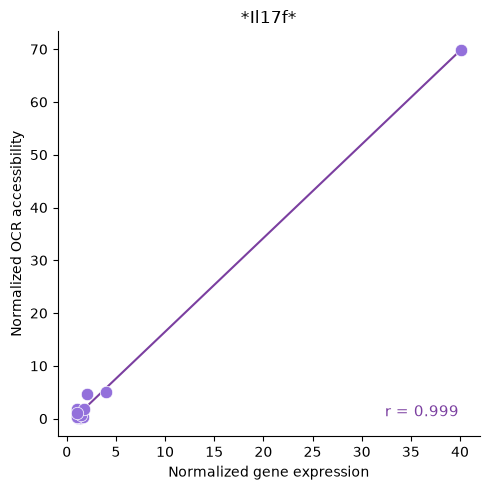

In [71]:
# Stärkstes Gen aus sig auswählen (höchstes r)
best = corr_fdr_tgd.loc[corr_fdr_tgd['r'].idxmax()]
gene_name = best['gene']
peak_name_tgd = best['peak_id']

atac_vec = ATAC_Tgd.loc[ATAC_Tgd['ImmGenATAC1219.peakID'] == peak_name_tgd, Tgd_cells].values.flatten()
rna_vec  = RNA_Tgd.loc[gene_name, Tgd_cells].values.flatten()

r_val = best['r']

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rna_vec, atac_vec, color='mediumpurple', edgecolors='white', 
           linewidths=0.5, s=80, zorder=3)


m, b = np.polyfit(rna_vec, atac_vec, 1)
x_line = np.linspace(rna_vec.min(), rna_vec.max(), 100)
ax.plot(x_line, m * x_line + b, color='#7B3FA0', linewidth=1.5)

ax.set_xlabel("Normalized gene expression")
ax.set_ylabel("Normalized OCR accessibility")
ax.set_title(f"*{gene_name}*")
ax.text(0.95, 0.05, f"r = {r_val:.3f}", transform=ax.transAxes,
        ha='right', fontsize=11, color='#7B3FA0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

<b> alle Zellen rein, die IL17f exprimieren/ alle T-Zellen

In [72]:
peak_name_tgd

'ImmGenATAC1219.peak_2086'

In [73]:
ATAC_pfiltered[ATAC_pfiltered['ImmGenATAC1219.peakID'] == peak_name_tgd]

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2085,ImmGenATAC1219.peak_2086,chr1,20744070,0.0,7.53,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.41,0.1,...,0.44,0.36,0.11,0.53,0.11,0.56,1.26,0.11,1.04,1.26


In [74]:
# Signal des Peaks über alle Tgd-Zelltypen anzeigen
peak_row = ATAC_pfiltered[ATAC_pfiltered['ImmGenATAC1219.peakID'] == peak_name_tgd]

# Nur die Signal-Spalten (Zelltypen)
peak_signal = peak_row[Tgd_cells].T  # T = transponieren, damit Zelltypen als Zeilen
peak_signal.columns = ['Signal']
peak_signal = peak_signal.sort_values('Signal', ascending=False)

print(peak_signal)

                     Signal
Tgd.g2+d17.LN         69.89
Tgd.g2+d1.LN           5.03
Tgd.Sp                 4.63
Tgd.g2+d17.24a+.Th     1.91
preT.DN2a.Th           1.88
preT.DN1.Th            1.11
Tgd.g1.1+d1.LN         0.99
Tgd.g2+d1.24a+.Th      0.76
Tgd.g1.1+d1.24a+.Th    0.40
T.DN4.Th               0.35
preT.DN3.Th            0.22
preT.DN2b.Th           0.11
MPP4.135+.BM           0.11


--> Enhancer! ist ein peak, der im IL17a lokus liegt und eine hohe korrelation zwischen offenheit uns IL17f expression besitzt.... Er wird besonders oft in Tgd Zellen exprimiert

<b> IL17f Korrelation (Expression vs OCR) über alle zelltypen

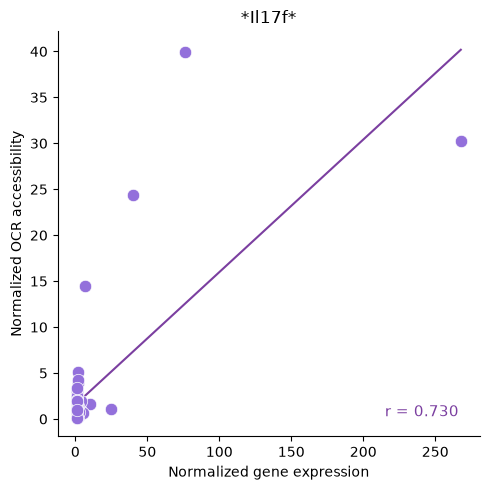

In [ ]:
gene_of_interest = 'Il17f'

# Bestes Peak für Il17f aus der All-Cells-Korrelation
subset = corr_fdr_all[corr_fdr_all['gene'] == gene_of_interest]
best_all = subset.loc[subset['r'].idxmax()]
peak_name_all = best_all['peak_id']
r_val = best_all['r']

# Vektoren über 90 Zelltypen
atac_vec = ATAC_pfiltered.loc[
    ATAC_pfiltered['ImmGenATAC1219.peakID'] == peak_name_all, signal_cols_all
].values.flatten()

rna_vec = RNA_seq.loc[gene_of_interest, signal_cols_all].values.flatten()

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rna_vec, atac_vec, color='mediumpurple', edgecolors='white',
           linewidths=0.5, s=80, zorder=3)

m, b = np.polyfit(rna_vec, atac_vec, 1)
x_line = np.linspace(rna_vec.min(), rna_vec.max(), 100)
ax.plot(x_line, m * x_line + b, color='#7B3FA0', linewidth=1.5)

ax.set_xlabel("Normalized gene expression")
ax.set_ylabel("Normalized OCR accessibility")
ax.set_title(f"*{gene_of_interest}*")
ax.text(0.95, 0.05, f"r = {r_val:.3f}", transform=ax.transAxes,
        ha='right', fontsize=11, color='#7B3FA0')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

"Il17f, a cytokine characteristically produced by γδT cells (Yoshida et al., 2019), shows a robust correlation (r = 0.730) between OCR accessibility and gene expression across all 90 immune cell types. The majority of cell types — including B cells, NK cells, and myeloid populations — show both low Il17f expression and low chromatin accessibility at this locus. In contrast, γδT cells and ILC3s, known producers of Il17 family cytokines, cluster at higher expression and accessibility values. This demonstrates that CRE activity at the Il17f locus is tightly linked to lineage-specific gene expression, consistent with the principle that correlation of chromatin accessibility with gene expression across diverse cell types can identify functionally relevant cis-regulatory elements (Yoshida et al., 2019; Calderon et al., 2019)."

In [76]:
peak_name_all

'ImmGenATAC1219.peak_2095'

In [77]:
ATAC_pfiltered[ATAC_pfiltered['ImmGenATAC1219.peakID'] == peak_name_all]

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2094,ImmGenATAC1219.peak_2095,chr1,20784347,0.55,11.49,1.0,Il17f,"Il17a,Il17f,Mcm3",0.41,0.71,...,2.1,1.81,1.14,0.11,1.82,1.94,0.1,1.92,3.39,0.94


In [78]:
# Signal des Peaks über alle Tgd-Zelltypen anzeigen
peak_row = ATAC_pfiltered[ATAC_pfiltered['ImmGenATAC1219.peakID'] == peak_name_all]

# Nur die Signal-Spalten (Zelltypen)
peak_signal = peak_row[Tgd_cells].T  # T = transponieren, damit Zelltypen als Zeilen
peak_signal.columns = ['Signal']
peak_signal = peak_signal.sort_values('Signal', ascending=False)

print(peak_signal)

                     Signal
Tgd.g2+d17.LN         24.37
Tgd.g2+d17.24a+.Th     5.12
Tgd.Sp                 4.21
Tgd.g1.1+d1.24a+.Th    2.51
preT.DN1.Th            2.09
Tgd.g2+d1.24a+.Th      2.07
Tgd.g2+d1.LN           1.95
preT.DN2b.Th           1.78
MPP4.135+.BM           1.58
preT.DN2a.Th           1.17
preT.DN3.Th            1.01
Tgd.g1.1+d1.LN         0.99
T.DN4.Th               0.78


--> Promoter... Hier haben wir also einen peak, der eine große korrelation mit Il17f aufweist, wenn man pber alle zellen geht... Das ist ein andere peak, als wenn man sich nur die Tgd zellen anschaut... Dieser peak ist allerdings wahrscheinlich promoter-driven.

Peak aus Tgd-Korrelation (höchstes r, TSS = NaN → Enhancer):  <br>
Dieser Peak ist ein distaler Enhancer, er liegt zwar in der Nähe von Il17f (innerhalb 100kb), aber nicht direkt am Promoter. Das er in der Tgd-spezifischen Korrelation am stärksten ist, bedeutet: seine Zugänglichkeit variiert stark zwischen den γδT-Subtypen und korreliert mit Il17f-Expression. Das ist biologisch sehr interessant; Enhancer sind oft zelltyp- und aktivierungsspezifisch. Dieser Peak könnte ein γδT-spezifischer Enhancer sein, der Il17f nur in bestimmten 
γδT-Subtypen (z.B. Tgd.g2+d17) aktiviert. <p>
Peak aus All-Cells-Korrelation (höchstes r, TSS = Il17f → Promoter): <br>
Dieser Peak ist der Promoter von Il17f selbst. Er korreliert gut über alle 90 Zelltypen, weil der Promoter in allen Il17f-exprimierenden Zellen (γδT + ILC3) zugänglich sein muss, das ist eine "konstitutivere" Regulation. Promoter-Zugänglichkeit ist oft weniger zelltyp-spezifisch als Enhancer-Zugänglichkeit.

<b> zwei höchste Peaks: Promoter vs Enhancer 

Both the distal enhancer and promoter-proximal OCRs at the Il17f locus show highest chromatin accessibility in Tgd.g2+d17 cells — the IL-17-producing γδT subtype implicated in psoriatic inflammation (Veras et al., 2022). Notably, the distal enhancer OCR shows higher accessibility (signal 69.89) than the promoter (24.37) in Tgd.g2+d17.LN cells, consistent with the established role of lineage-specific enhancers as primary drivers of cell-type-restricted gene expression (Yoshida et al., 2019; Corces et al., 2018). This pattern demonstrates that CRE activity at the Il17f locus is tightly restricted to IL-17-competent γδT cells, and supports a model in which enhancer-driven chromatin remodeling precedes and facilitates promoter activation — as previously described for immune cell differentiation (Buenrostro et al., 2013; Calderon et al., 2019)."

<b> Interpretation der Unterschiede in ATAC-SIgnal stärke zwischen höchsten Peak tgd (enhancer) und höchstem peak (promoter):

"Genome-wide, promoter OCRs show higher mean accessibility than enhancer OCRs across all 90 immune cell types, consistent with their role as constitutively open regulatory elements (Buenrostro et al., 2013; Yoshida et al., 2019). In contrast, enhancer OCRs exhibit greater signal variability (higher CV), reflecting their cell-type-specific activation patterns (Corces et al., 2018; Calderon et al., 2019). This pattern is exemplified at the Il17f locus: while the promoter shows moderate accessibility across cell types, the distal enhancer OCR displays extremely high accessibility specifically in Tgd.g2+d17 cells (signal 69.89 vs. ~0.1–2 in other cell types), demonstrating the hallmark behavior of a lineage-specific enhancer driving Il17f expression selectively in IL-17-producing γδT cells implicated in psoriatic inflammation (Veras et al., 2022)."

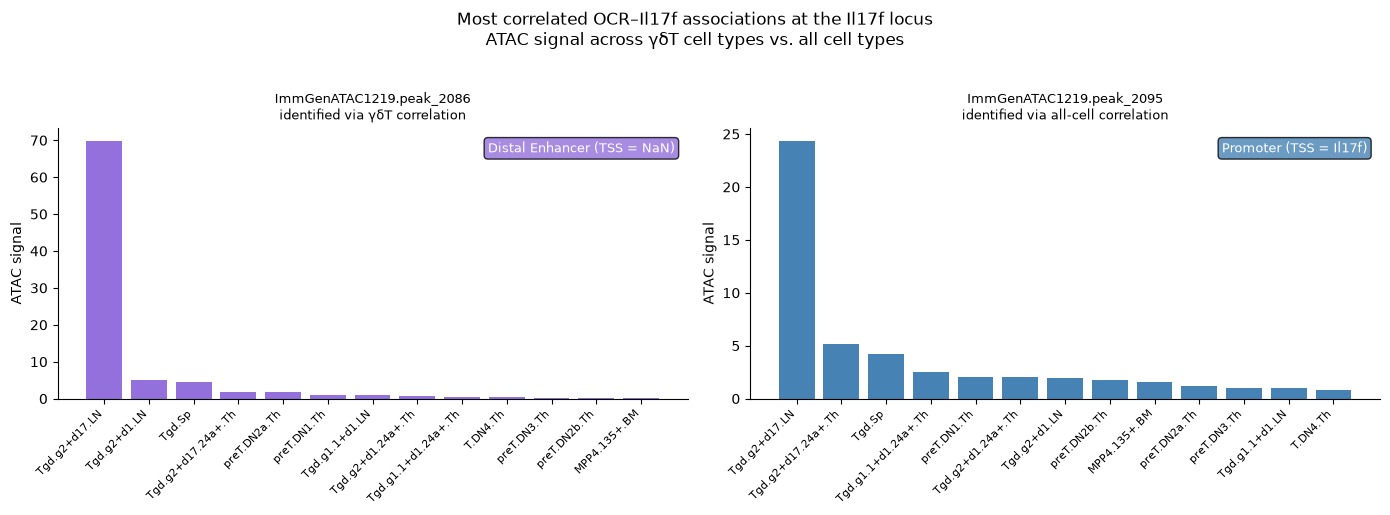

In [79]:
peak_2086 = "ImmGenATAC1219.peak_2086"  # Enhancer-Peak (identified via γδT correlation)
peak_2095 = "ImmGenATAC1219.peak_2095"  # Promoter-Peak (identified via all-cell correlation)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, peak, color, label in zip(
    axes,
    [peak_2086, peak_2095],
    ['mediumpurple', 'steelblue'],
    ['Distal Enhancer (TSS = NaN)\nidentified via γδT correlation',
     'Promoter (TSS = Il17f)\nidentified via all-cell correlation']
):
    row = ATAC_Tgd[ATAC_Tgd['ImmGenATAC1219.peakID'] == peak]
    signal = row[Tgd_cells].T
    signal.columns = ['Signal']
    signal = signal.sort_values('Signal', ascending=False)

    ax.bar(range(len(signal)), signal['Signal'], color=color)
    ax.set_xticks(range(len(signal)))
    ax.set_xticklabels(signal.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel("ATAC signal")
    ax.set_title(
    f"{peak}\nidentified via {'γδT' if peak == peak_2086 else 'all-cell'} correlation",
    fontsize=9
)
    ax.annotate(label.split('\n')[0],
                xy=(0.98, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=9, color='white',
                bbox=dict(boxstyle='round', fc=color, alpha=0.8))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    "Most correlated OCR–Il17f associations at the Il17f locus\n"
    "ATAC signal across γδT cell types vs. all cell types",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

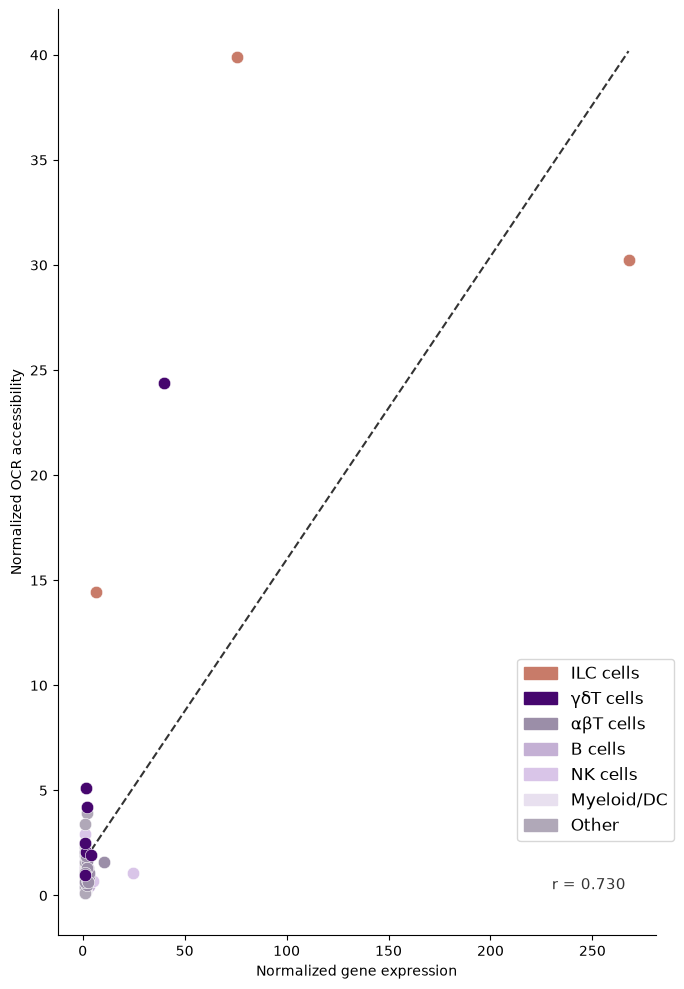

In [113]:
# Zelltyp-Kategorien definieren
import matplotlib.patches as mpatches
def get_cell_category(col):
    if 'Tgd' in col:
        return 'γδT cells'
    elif 'ILC' in col:
        return 'ILC cells'
    elif col.startswith('T.') or col.startswith('T8') or col.startswith('Treg') or 'preT' in col:
        return 'αβT cells'
    elif col.startswith('B.') or col.startswith('proB') or col.startswith('preB'):
        return 'B cells'
    elif col.startswith('NK'):
        return 'NK cells'
    elif col.startswith('MF') or col.startswith('Mo') or col.startswith('DC') or col.startswith('GN'):
        return 'Myeloid/DC'
    else:
        return 'Other'

# Farben pro Kategorie
color_map = {
    'ILC cells':   "#C87B69",
    'γδT cells':   "#46066E",  
    'αβT cells':   "#9B8EA8",  
    'B cells':     "#C4B0D4",  
    'NK cells':    "#D9C5E8",  
    'Myeloid/DC':  "#E8E0EF",  
    'Other':       "#B0A8B8"   
}

handles = [
    mpatches.Patch(color=color, label=label) 
    for label, color in color_map.items()  # Reihenfolge aus dem Dict
]


# DataFrame für Plot erstellen
plot_df = pd.DataFrame({
    'rna':      rna_vec,
    'atac':     atac_vec,
    'celltype': [get_cell_category(c) for c in signal_cols_all]
})

# Plot
fig, ax = plt.subplots(figsize=(7, 10))

for cat, group in plot_df.groupby('celltype'):
    ax.scatter(group['rna'], group['atac'],
               color=color_map[cat], label=cat,
               edgecolors='white', linewidths=0.4,
               s=80, zorder=3)

# Regressionslinie
m, b = np.polyfit(rna_vec, atac_vec, 1)
x_line = np.linspace(rna_vec.min(), rna_vec.max(), 100)
ax.plot(x_line, m * x_line + b, color='#333333', linewidth=1.5, linestyle='--')

ax.set_xlabel("Normalized gene expression")
ax.set_ylabel("Normalized OCR accessibility")
#ax.set_title("Il17f — OCR accessibility vs. gene expression")
ax.text(0.95, 0.05, f"r = {r_val:.3f}", transform=ax.transAxes,
        ha='right', fontsize=11, color='#333333')
ax.legend(handles=handles, loc='center', bbox_to_anchor=(0.9, 0.2), 
          frameon=True, fontsize=12,
          framealpha=0.9, edgecolor='lightgrey')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig('plots_for_poster/scatterplot IL17f- OCR accessibility vs gene expression.png', dpi= 300, bbox_inches='tight')
plt.tight_layout()
plt.show()

<b> schauen, ob in unseren peaks die transkriptionsmotifen vorkommen (5. Datensatz)


<h3> Are Promoters usually associated with their own genes?

In [81]:
promoter_peaks = ATAC_promoters[['ImmGenATAC1219.peakID', 'TSS']]

#welche Promoter-Peaks haben signifikante Assoziationen
promoter_corr_fdr = corr_fdr_tgd.merge(
    promoter_peaks, 
    left_on='peak_id', 
    right_on='ImmGenATAC1219.peakID'
)

# assoziierte Gen dasselbe wie Gen in der TSS-Spalte
promoter_corr_fdr['own_gene'] = promoter_corr_fdr['gene'] == promoter_corr_fdr['TSS']

#jeder peak zählt nur einmal
print(f"Promoter assoziert mit eigenem Gen: {promoter_corr_fdr[promoter_corr_fdr['own_gene']]['peak_id'].nunique()}")
print(f"Promoter assoziert mit anderem Gen: {promoter_corr_fdr[~promoter_corr_fdr['own_gene']]['peak_id'].nunique()}")
print(f"Promoter mit signifikanten Assoziationen insgesamt: {promoter_corr_fdr['peak_id'].nunique()}")


Promoter assoziert mit eigenem Gen: 313
Promoter assoziert mit anderem Gen: 273
Promoter mit signifikanten Assoziationen insgesamt: 525


Von 525  Promoter-peaks mit signifikantem assoziertem Gen, sind 313 mit ihrem eigenen Gen assoziert und 273 mit einem anderen Gen... Aus diesen Zahlen kann man außerdem ablesen, dass 51 Promotoren-Peaks sowohl mit ihrem eigenen Gen, als auch mit anderen genen assoziert sind.

<h3> Peaks with multiple genes:

In [82]:
peaks_per_gene = corr_fdr_tgd.groupby('peak_id')['gene'].nunique()
peaks_mehrere_Gene = peaks_per_gene[peaks_per_gene > 1]
print(f"\nPeaks assoziiert mit mehreren Genen: {len(peaks_mehrere_Gene)}")
print(f"\nPeaks signifkant assoziiert allgemein : {len(corr_fdr_tgd)}")
print(peaks_mehrere_Gene.sort_values(ascending=False).head(10))


Peaks assoziiert mit mehreren Genen: 900

Peaks signifkant assoziiert allgemein : 9640
peak_id
ImmGenATAC1219.peak_397061    8
ImmGenATAC1219.peak_397075    7
ImmGenATAC1219.peak_397067    7
ImmGenATAC1219.peak_397119    7
ImmGenATAC1219.peak_397057    6
ImmGenATAC1219.peak_246655    6
ImmGenATAC1219.peak_397112    6
ImmGenATAC1219.peak_74475     5
ImmGenATAC1219.peak_415594    5
ImmGenATAC1219.peak_246632    5
Name: gene, dtype: int64
